# DSCI 552 - Homework 2
**Yang Zhao**  
**USC NetID:** yzhao528

This notebook uses **Sheet1** of `Folds5x2_pp.xlsx`, as required.

## 1(a) Data and reproducibility
The included workbook comes from the [UCI Combined Cycle Power Plant dataset](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant). Only Sheet1 is used; the other sheets are shuffled copies and are not concatenated. AT and PE correspond to T and EP in the assignment. No observations are removed or imputed. Run this notebook from the repository root using the dependencies in `requirements.txt`. The 70/30 split uses `random_state=42`.


In [1]:
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error

data_path = Path("CCPP") / "Folds5x2_pp.xlsx"
if not data_path.is_file():
    raise FileNotFoundError("Open the notebook from the repository root; expected CCPP/Folds5x2_pp.xlsx.")
df = pd.read_excel(data_path, sheet_name="Sheet1")
assert list(df.columns) == ["AT", "V", "AP", "RH", "PE"]
assert df.shape == (9568, 5) and not df.isna().any().any()
print(f"Rows: {df.shape[0]:,}; columns: {df.shape[1]}; missing values: {df.isna().sum().sum()}")
display(df.head())

Rows: 9,568; columns: 5; missing values: 0


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1(b) Exploring the data
### (i) Rows and columns
There are **9,568 rows and 5 columns**. Each row is an hourly observation collected while the plant operated at full load during 2006-2011. The predictors are AT (ambient temperature, degrees C), V (exhaust vacuum, cm Hg), AP (ambient pressure, millibar), and RH (relative humidity, %). PE is the net hourly electrical energy output (MW), the response.

### (ii) Pairwise scatterplots
The matrix includes all five variables, including the response PE.

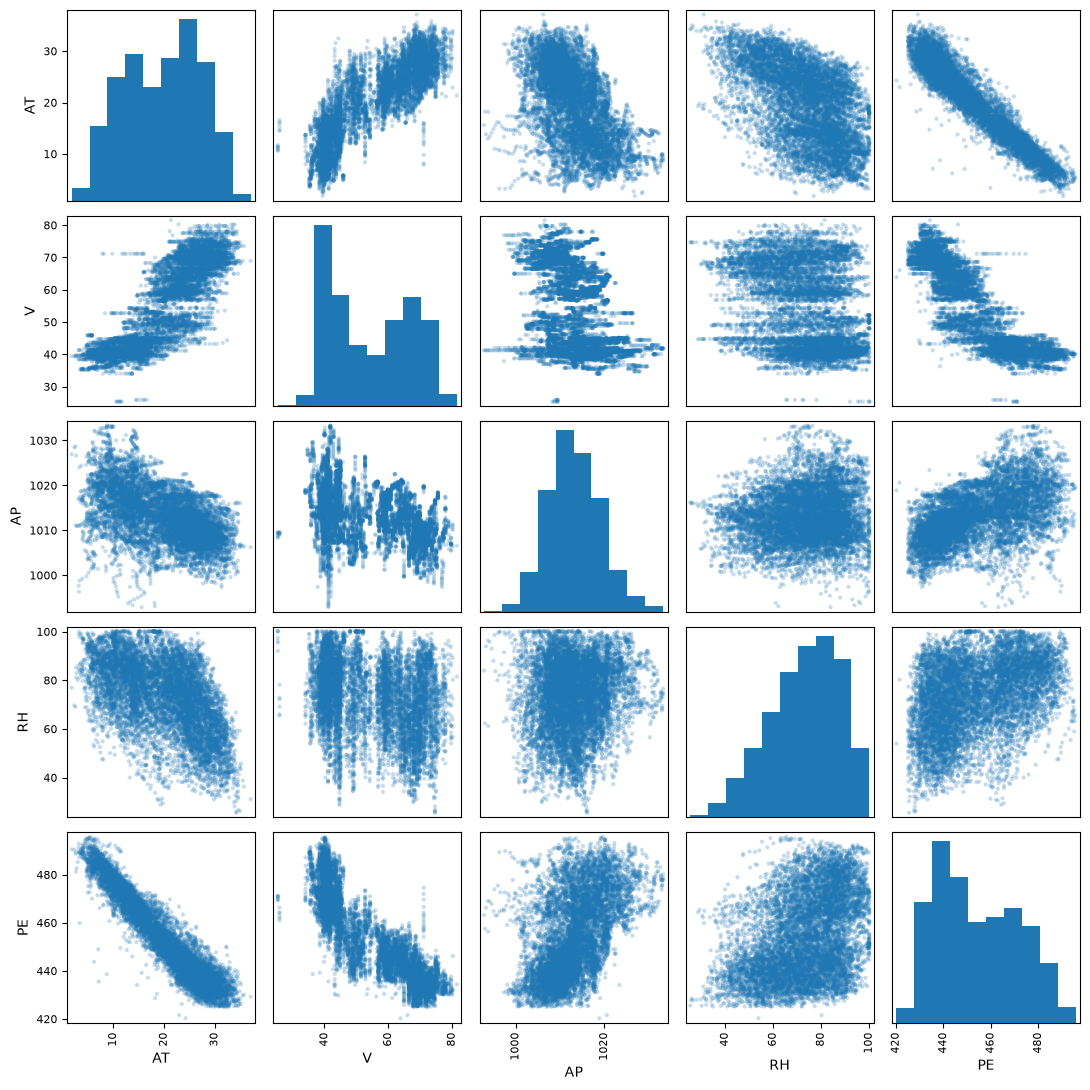

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


In [2]:
pd.plotting.scatter_matrix(df, figsize=(11,11), diagonal="hist", alpha=.25)
plt.tight_layout()
plt.show()
df.corr()

**Findings.** PE is strongly negatively associated with AT and V, moderately positively associated with AP, and more weakly positively associated with RH. AT and V are themselves strongly positively correlated, so coefficient changes are expected when moving from simple to multiple regression.

### (iii) Descriptive statistics
Range is maximum minus minimum; IQR is the third quartile minus the first quartile. The table below summarizes all five variables.

In [3]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max()-df.min(),
    "Q1": df.quantile(.25),
    "Q3": df.quantile(.75),
    "IQR": df.quantile(.75)-df.quantile(.25)
})
summary

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


## 1(c) Simple linear regressions

AT intercept= 497.0341198927669 coef= -2.171319958517796 p= 0.0 R2= 0.8989475964148237


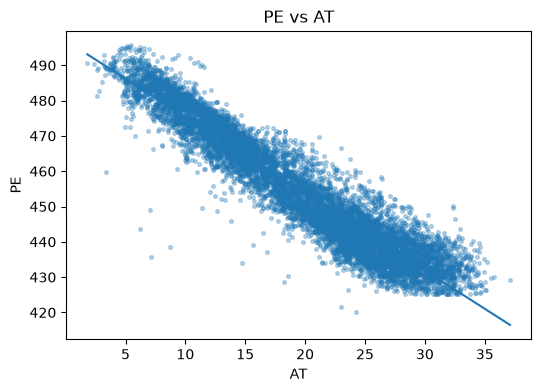

V intercept= 517.8015263083856 coef= -1.168135126555711 p= 0.0 R2= 0.7565177870683977


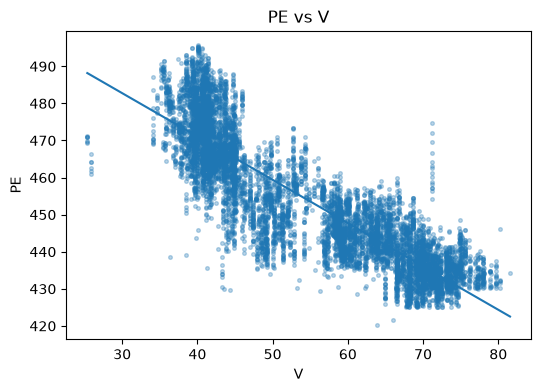

AP intercept= -1055.2609889844402 coef= 1.4898716733991142 p= 0.0 R2= 0.2687686564110675


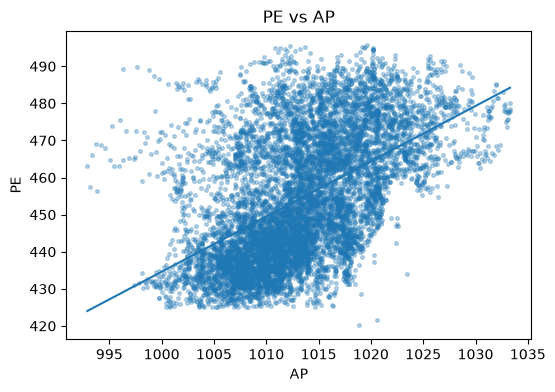

RH intercept= 420.96176615548393 coef= 0.45565010226298064 p= 0.0 R2= 0.151939440231176


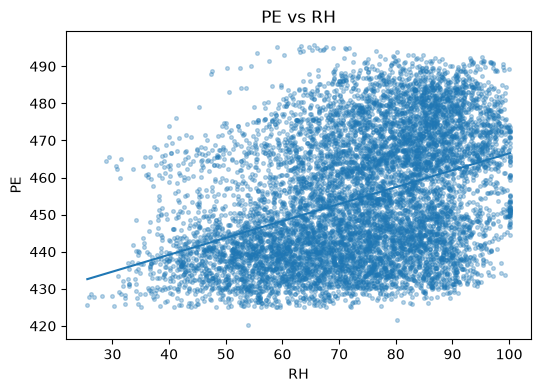

In [4]:
X = df[["AT","V","AP","RH"]]
y = df["PE"]
uni = {}
for col in X.columns:
    m = sm.OLS(y, sm.add_constant(X[[col]])).fit()
    uni[col] = m
    print(col, "intercept=", m.params["const"], "coef=", m.params[col], "p=", m.pvalues[col], "R2=", m.rsquared)
    order = np.argsort(X[col].values)
    plt.figure(figsize=(6,4))
    plt.scatter(X[col], y, s=7, alpha=.3)
    plt.plot(X[col].values[order], m.predict(sm.add_constant(X[[col]])).values[order])
    plt.xlabel(col); plt.ylabel("PE"); plt.title(f"PE vs {col}")
    plt.show()

In [5]:
diagnostics = []
for col, model in uni.items():
    influence = model.get_influence()
    diagnostics.append({
        "Predictor": col,
        "Intercept": model.params["const"],
        "Slope": model.params[col],
        "p-value": model.pvalues[col],
        "R-squared": model.rsquared,
        "Count |internally studentized residual| > 3": int((np.abs(influence.resid_studentized_internal) > 3).sum()),
        "Maximum Cook's D": influence.cooks_distance[0].max()
    })
diagnostics = pd.DataFrame(diagnostics).set_index("Predictor")
display(diagnostics)

,Intercept,Slope,p-value,R-squared,Count |internally studentized residual| > 3,Maximum Cook's D
Predictor,,,,,,
AT,497.034120,-2.171320,0.0,0.898948,42,0.014325
V,517.801526,-1.168135,0.0,0.756518,33,0.003243
AP,-1055.260989,1.489872,0.0,0.268769,29,0.008152
RH,420.961766,0.455650,0.0,0.151939,2,0.002059


All four simple-regression slopes are statistically significant at the 0.05 level. AT and V have negative slopes; AP and RH have positive slopes. AT alone explains about 89.9% of the response variance, compared with 75.7% for V, 26.9% for AP, and 15.2% for RH. Printed p-values of zero reflect numerical underflow, not an exactly zero probability.

There are 42, 33, 29, and 2 observations with absolute internally studentized residuals above 3 in the AT, V, AP, and RH models, respectively. Their maximum Cook's distances are approximately 0.0143, 0.0032, 0.0082, and 0.0021. These are diagnostic flags rather than automatic deletion rules. Small Cook's distances do not prove that no outliers exist. Without evidence of measurement errors, I retain all observations in each model rather than delete points solely to improve fit.

## 1(d)-(e) Multiple regression and coefficient comparison

In [6]:
multi = sm.OLS(y, sm.add_constant(X)).fit()
print(multi.summary())
coef_compare = pd.DataFrame({
    "Simple": [uni[c].params[c] for c in X.columns],
    "Multiple": multi.params[X.columns]
}, index=X.columns)
coef_compare


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:50:29   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

,Simple,Multiple
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


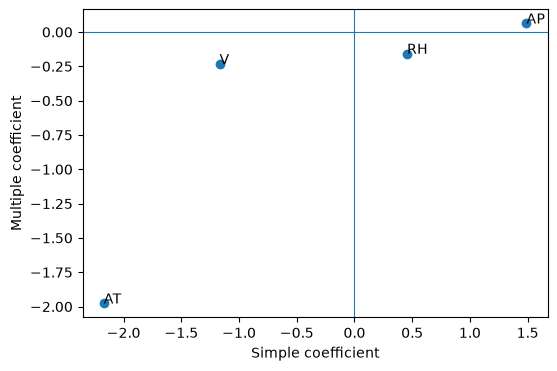

In [7]:
plt.figure(figsize=(6,4))
plt.scatter(coef_compare["Simple"], coef_compare["Multiple"])
for n,row in coef_compare.iterrows(): plt.annotate(n,(row["Simple"],row["Multiple"]))
plt.axhline(0, linewidth=.8); plt.axvline(0, linewidth=.8)
plt.xlabel("Simple coefficient"); plt.ylabel("Multiple coefficient"); plt.show()

All four predictors (AT, V, AP, and RH) have p-values below 0.05 in the multiple regression, so we reject each null hypothesis $H_0: \beta_j=0$. The model has $R^2 \approx 0.9287$:

$$\widehat{PE} = 454.6093 - 1.9775 AT - 0.2339 V + 0.0621 AP - 0.1581 RH.$$

RH reverses sign after adjustment, while AP and V shrink substantially in magnitude. AT remains strongly negative. These differences reflect predictor correlations and the distinction between marginal and adjusted associations; they do not establish causal effects.

## 1(f) Cubic models

In [8]:
nonlinear_results = []
for col in X.columns:
    z = (X[col] - X[col].mean()) / X[col].std(ddof=0)
    cubic = sm.OLS(y, sm.add_constant(np.column_stack([z, z**2, z**3]))).fit()
    linear = sm.OLS(y, sm.add_constant(z)).fit()
    f_stat, p_joint, df_diff = cubic.compare_f_test(linear)
    nonlinear_results.append({
        "Predictor": col,
        "p(z^2)": cubic.pvalues.iloc[2],
        "p(z^3)": cubic.pvalues.iloc[3],
        "Joint nonlinear p-value": p_joint,
        "Cubic R-squared": cubic.rsquared
    })
display(pd.DataFrame(nonlinear_results).set_index("Predictor"))

,p(z^2),p(z^3),Joint nonlinear p-value,Cubic R-squared
Predictor,,,,
AT,3.311808e-231,3.652185e-110,3.478379e-285,0.911883
V,8.977010e-131,1.373489e-02,7.040304e-165,0.775022
AP,2.192722e-46,2.123338e-67,4.209145e-84,0.297543
RH,1.013949e-01,1.440279e-05,3.799622e-05,0.153743


Centering and scaling before taking powers improves numerical stability and spans the same cubic model space as $1, X, X^2, X^3$. The joint F-test compares the cubic model with its nested linear model, testing that both added nonlinear coefficients are zero. There is evidence of nonlinearity for every predictor. For RH, the squared term is not individually significant (p about 0.1014), but the cubic term and joint nonlinear test are significant. Lower-order terms are retained when higher-order terms are included.

## 1(g) Full pairwise-interaction model

In [9]:
M = X.copy()
for a,b in combinations(X.columns,2): M[f"{a}:{b}"] = X[a]*X[b]
inter = sm.OLS(y, sm.add_constant(M)).fit()
print(inter.summary())
interaction_terms = [name for name in M.columns if ":" in name]
display(pd.DataFrame({"Coefficient": inter.params[interaction_terms], "p-value": inter.pvalues[interaction_terms], "Significant at 0.05": inter.pvalues[interaction_terms] < .05}))


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:50:29   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

,Coefficient,p-value,Significant at 0.05
AT:V,0.020971,3.333358e-117,True
AT:AP,0.001759,4.520509e-01,False
AT:RH,-0.005230,1.216944e-10,True
V:AP,0.006812,2.877026e-07,True
V:RH,0.000839,8.619366e-02,False
AP:RH,-0.001612,3.360557e-02,True


At the 0.05 level, significant interactions are AT:V, AT:RH, V:AP, and AP:RH.

## 1(h) 70/30 split; selected quadratic + interactions

Both models use the same random 70/30 split. Centering and scaling for the expanded model are fitted on the training set only. The expanded model starts with all four main effects, four squares, and six pairwise interactions. Backward elimination removes the eligible term with the largest p-value above 0.05. A main effect is retained whenever a remaining square or interaction depends on it, preserving model hierarchy.


In [10]:
idx=np.arange(len(df))
tr,te=train_test_split(idx,test_size=.30,random_state=42)
Xtr,Xte=X.iloc[tr].to_numpy(),X.iloc[te].to_numpy(); ytr,yte=y.iloc[tr].to_numpy(),y.iloc[te].to_numpy()
base=sm.OLS(ytr,sm.add_constant(Xtr)).fit()
print("Linear train/test MSE:", mean_squared_error(ytr,base.predict(sm.add_constant(Xtr))), mean_squared_error(yte,base.predict(sm.add_constant(Xte))))

mu=Xtr.mean(0); sd=Xtr.std(0); Ztr=(Xtr-mu)/sd; Zte=(Xte-mu)/sd; cols=list(X.columns)
fn=[]; fv=[]; Atr=[]; Ate=[]
for i,n in enumerate(cols): fn.append(n); fv.append((i,)); Atr.append(Ztr[:,i]); Ate.append(Zte[:,i])
for i,n in enumerate(cols): fn.append(n+"^2"); fv.append((i,i)); Atr.append(Ztr[:,i]**2); Ate.append(Zte[:,i]**2)
for i,j in combinations(range(4),2): fn.append(cols[i]+":"+cols[j]); fv.append((i,j)); Atr.append(Ztr[:,i]*Ztr[:,j]); Ate.append(Zte[:,i]*Zte[:,j])
Atr=np.column_stack(Atr); Ate=np.column_stack(Ate); active=list(range(len(fn)))
def eligible(k):
    if len(fv[k])==2: return True
    i=fv[k][0]
    return not any(a!=k and len(fv[a])==2 and i in fv[a] for a in active)
removed=[]
while True:
    fit=sm.OLS(ytr,sm.add_constant(Atr[:,active])).fit()
    cand=[(float(p),k) for p,k in zip(fit.pvalues[1:],active) if p>.05 and eligible(k)]
    if not cand: break
    p,k=max(cand); removed.append((fn[k],p)); active.remove(k)
fit=sm.OLS(ytr,sm.add_constant(Atr[:,active])).fit()
print("Removed:",removed)
print("Kept:",[fn[k] for k in active])
print("Selected model train/test MSE:",mean_squared_error(ytr,fit.predict(sm.add_constant(Atr[:,active]))),mean_squared_error(yte,fit.predict(sm.add_constant(Ate[:,active]))))

Linear train/test MSE: 20.58083972573869 21.239856938225493
Removed: [('V:RH', 0.8673823758763545), ('V^2', 0.607732770055514), ('V:AP', 0.3578255038419005)]
Kept: ['AT', 'V', 'AP', 'RH', 'AT^2', 'AP^2', 'RH^2', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']
Selected model train/test MSE: 17.89084277318502 18.660040495062674


The selected model removes V:RH, V^2, and V:AP in that order. It retains AT, V, AP, RH, AT^2, AP^2, RH^2, AT:V, AT:AP, AT:RH, and AP:RH. Test MSE falls from about 21.2399 to 18.6600, an improvement of 12.1%; training MSE falls from 20.5808 to 17.8908.

## 1(i) KNN regression
Both versions use uniform neighbor weights and Euclidean distance, evaluating every integer k from 1 to 100 on the same split as part (h). "Normalized" here means z-score standardization with `StandardScaler`, fitted only on the training predictors. Cumulative neighbor averages give the same predictions as uniform-weight KNN regression for each k. Training predictions include the query observation itself, as in ordinary in-sample prediction. The plots show train and test MSE against 1/k.

Raw best k: 5 test MSE 15.726819842563568
Normalized best k: 4 test MSE 14.305669422675024


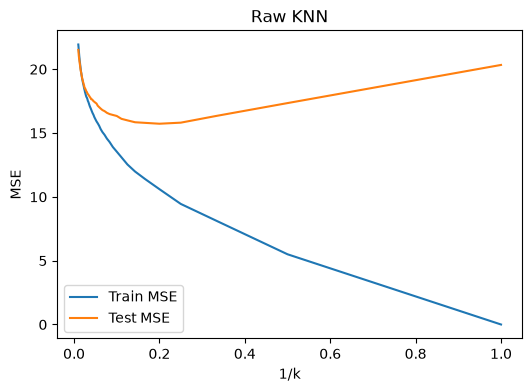

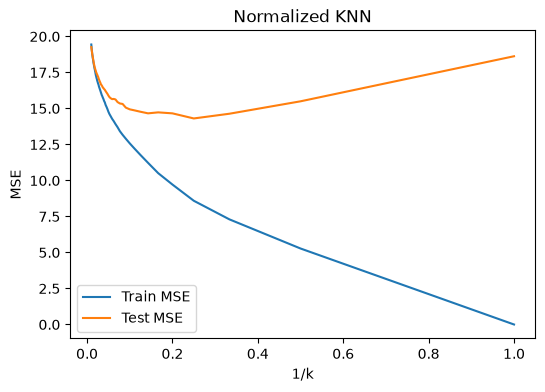

In [11]:
def curves(A,B,ya,yb,maxk=100):
    nn=NearestNeighbors(n_neighbors=maxk,n_jobs=-1).fit(A)
    ia=nn.kneighbors(A,return_distance=False); ib=nn.kneighbors(B,return_distance=False)
    ca=np.cumsum(ya[ia],axis=1); cb=np.cumsum(ya[ib],axis=1)
    tr=[]; te=[]
    for k in range(1,maxk+1):
        tr.append(np.mean((ya-ca[:,k-1]/k)**2)); te.append(np.mean((yb-cb[:,k-1]/k)**2))
    return np.array(tr),np.array(te)
raw_tr,raw_te=curves(Xtr,Xte,ytr,yte)
sc=StandardScaler().fit(Xtr); norm_tr,norm_te=curves(sc.transform(Xtr),sc.transform(Xte),ytr,yte)
print("Raw best k:",np.argmin(raw_te)+1,"test MSE",raw_te.min())
print("Normalized best k:",np.argmin(norm_te)+1,"test MSE",norm_te.min())
for title,trerr,teerr in [("Raw",raw_tr,raw_te),("Normalized",norm_tr,norm_te)]:
    plt.figure(figsize=(6,4)); inv=1/np.arange(1,101)
    plt.plot(inv,trerr,label="Train MSE"); plt.plot(inv,teerr,label="Test MSE")
    plt.xlabel("1/k"); plt.ylabel("MSE"); plt.title(title+" KNN"); plt.legend(); plt.show()

In [12]:
raw_k = int(np.argmin(raw_te)) + 1
norm_k = int(np.argmin(norm_te)) + 1
model_comparison = pd.DataFrame([
    {"Model": "All-predictor linear", "Best k": None,
     "Train MSE": mean_squared_error(ytr, base.predict(sm.add_constant(Xtr))),
     "Test MSE": mean_squared_error(yte, base.predict(sm.add_constant(Xte)))},
    {"Model": "Selected quadratic + interactions", "Best k": None,
     "Train MSE": mean_squared_error(ytr, fit.predict(sm.add_constant(Atr[:, active]))),
     "Test MSE": mean_squared_error(yte, fit.predict(sm.add_constant(Ate[:, active])))},
    {"Model": "Raw KNN", "Best k": raw_k,
     "Train MSE": raw_tr[raw_k - 1], "Test MSE": raw_te[raw_k - 1]},
    {"Model": "Standardized KNN", "Best k": norm_k,
     "Train MSE": norm_tr[norm_k - 1], "Test MSE": norm_te[norm_k - 1]}
]).set_index("Model")
model_comparison["Best k"] = model_comparison["Best k"].astype("Int64")
display(model_comparison)

,Best k,Train MSE,Test MSE
Model,,,
All-predictor linear,<NA>,20.580840,21.239857
Selected quadratic + interactions,<NA>,17.890843,18.660040
Raw KNN,5,10.600769,15.726820
Standardized KNN,4,8.591433,14.305669


## 1(j) Comparing KNN with regression
Raw-feature KNN is best at **k=5**, with test MSE about **15.7268**. Standardized KNN is best at **k=4**, with test MSE about **14.3057**, compared with **18.6600** for the selected quadratic/interaction regression. Thus standardized KNN lowers test MSE by about **23.3%** relative to the best regression model from part (h), consistent with its ability to capture local nonlinear patterns. Regression offers more compact coefficient-based summaries, although interaction terms require conditional interpretation.

Scaling helps on this split because Euclidean distance depends on differences in feature values, whose units and spreads differ. AP's mean near 1000 does not itself increase distances: a constant shift cancels when taking differences. Standardization changes each feature's relative contribution to distance.

The reported best k minimizes the plotted test MSE, following the exercise's train/test comparison. Since this same set is used to select k, its minimum MSE is a model-selection result rather than an independent final evaluation; a separate validation set or cross-validation would be appropriate for a new predictive study.

## 2. ISLR 2.4.1
(a) Flexible method: generally **better** when n is very large and p is small.  
(b) Flexible method: generally **worse** when p is very large and n is small, because of overfitting/high variance.  
(c) Flexible method: generally **better** when the true relationship is highly nonlinear.  
(d) Flexible method: generally **worse** when error variance is extremely high, because it can fit noise.

## 3. ISLR 2.4.7
Distances from (0,0,0): 3, 2, sqrt(10), sqrt(5), sqrt(2), sqrt(3).  
For K=1: **Green** (observation 5).  
For K=3: **Red** (neighbors 5, 6, and 2 give Green, Red, Red).  
With a highly nonlinear Bayes decision boundary, a **small K** is generally preferable because it yields a more flexible local decision boundary.

## References
- UCI Machine Learning Repository, Combined Cycle Power Plant dataset; supplied `CCPP/Readme.txt`.
- P. Tufekci (2014), "Prediction of full load electrical power output of a base load operated combined cycle power plant using machine learning methods," International Journal of Electrical Power & Energy Systems, 60, 126-140.
- H. Kaya, P. Tufekci, and S. F. Gurgen (2012), "Local and Global Learning Methods for Predicting Power of a Combined Gas & Steam Turbine," ICETCEE, 13-18.
- G. James, D. Witten, T. Hastie, and R. Tibshirani, An Introduction to Statistical Learning, Chapter 2, exercises 1 and 7.